# Egypt Real Estate Price Predictor — EDA, Cleaning & Modeling Pipeline

**Purpose of this notebook:** a first testable version of the pipeline that will eventually run automatically every 2 weeks (or whatever period you pick) as new data lands in `Supabase`. Everything below is organized into **reusable functions** so the whole flow — clean → engineer features → train → save model — can later be lifted into a script/cron job with minimal changes.

**Data:** `egypt_listings_raw.csv`, one snapshot pulled from your Supabase pipeline (44,133 listings, 14 columns, single `computed_at` timestamp).

**Sections:**
1. Load & first look
2. Exploratory Data Analysis (EDA)
3. Data cleaning (outliers, missing values, leakage columns)
4. Feature engineering
5. Train/test split
6. Model comparison (baseline → Ridge → RandomForest → HistGradientBoosting → LightGBM)
7. Final model evaluation + feature importance
8. Save the pipeline + a `retrain()` function for periodic automation
9. Notes for when this runs on a real recurring schedule


## 1. Setup & Load Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

import lightgbm as lgb

import arabic_reshaper
from bidi.algorithm import get_display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "egypt_listings_raw.csv"   


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 44,133 rows x 14 columns


,property_id,property_type,rooms,baths,area_m2,city,neighbourhood,price_egp,price_per_m2,is_outlier,active_listing_count,neighbourhood_avg_price_per_m2,days_on_market,computed_at
0,1,شقق,3.0,2.0,192.0,العاصمة الإدارية الجديدة,ار 8,5900000,30729.166667,False,1,33407.865329,0,2026-08-07 17:12:52.286789+00
1,2,دوبليكس,3.0,3.0,303.0,العاصمة الإدارية الجديدة,ار 8,10488300,34614.851485,False,1,33407.865329,0,2026-08-07 17:12:52.286789+00
2,3,شقق,3.0,2.0,145.0,القاهرة الجديدة,التجمع الخامس,10395000,71689.655172,False,1,72747.554095,0,2026-08-07 17:12:52.286789+00
3,4,شقق,4.0,2.0,190.0,سيدي بشر,NaN,4800000,25263.157895,False,1,26455.463042,0,2026-08-07 17:12:52.286789+00
4,5,شاليهات,3.0,3.0,160.0,الساحل الشمالي,NaN,19000000,118750.000000,False,1,111647.836111,0,2026-08-07 17:12:52.286789+00


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44133 entries, 0 to 44132
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   property_id                     44133 non-null  int64  
 1   property_type                   44133 non-null  object 
 2   rooms                           44091 non-null  float64
 3   baths                           44091 non-null  float64
 4   area_m2                         44133 non-null  float64
 5   city                            44133 non-null  object 
 6   neighbourhood                   30280 non-null  object 
 7   price_egp                       44133 non-null  int64  
 8   price_per_m2                    44133 non-null  float64
 9   is_outlier                      44133 non-null  bool   
 10  active_listing_count            44133 non-null  int64  
 11  neighbourhood_avg_price_per_m2  44133 non-null  float64
 12  days_on_market                  

## 2. Exploratory Data Analysis

Quick pass to understand missingness, cardinality, and — most importantly for a price model —
how skewed and how "dirty" the target (`price_egp`) actually is.


In [4]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
neighbourhood,13853,31.39
rooms,42,0.10
baths,42,0.10


In [5]:
# Cardinality of the categorical columns -- this matters a lot for encoding choice below.
for col in ["property_type", "city", "neighbourhood"]:
    print(f"{col:20s} -> {df_raw[col].nunique():,} unique values")


property_type        -> 14 unique values
city                 -> 121 unique values
neighbourhood        -> 529 unique values


`city` (121 unique) and `neighbourhood` (529 unique) are both **too high-cardinality for one-hot
encoding** — that would blow the feature space up into hundreds of mostly-empty columns. We'll use
target encoding for those two (details in the Feature Engineering section, with leakage handled
properly via `sklearn.preprocessing.TargetEncoder`'s built-in cross-fitting).


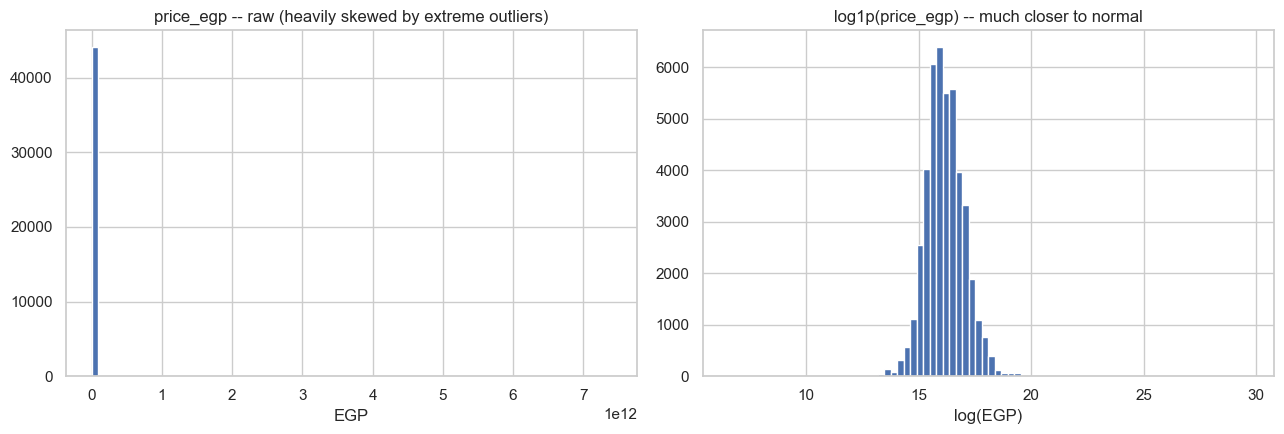

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df_raw["price_egp"], bins=80)
axes[0].set_title("price_egp -- raw (heavily skewed by extreme outliers)")
axes[0].set_xlabel("EGP")

axes[1].hist(np.log1p(df_raw.loc[df_raw["price_egp"] > 0, "price_egp"]), bins=80)
axes[1].set_title("log1p(price_egp) -- much closer to normal")
axes[1].set_xlabel("log(EGP)")
plt.tight_layout()
plt.show()


The raw target is unusable as-is: a handful of rows have prices in the **billions/trillions of EGP**
(almost certainly scraping/data-entry glitches -- e.g. a duplicated digit string, or a total-project
price attributed to a single unit). We'll model `log1p(price_egp)` throughout, which also matches how
real estate prices actually behave (multiplicative, not additive, errors).


In [7]:
print("is_outlier flag distribution:")
print(df_raw["is_outlier"].value_counts())
print()
print("price_per_m2 by is_outlier flag:")
df_raw.groupby("is_outlier")["price_per_m2"].describe()[["min", "25%", "50%", "75%", "max"]]


is_outlier flag distribution:
is_outlier
False    43249
True       884
Name: count, dtype: int64

price_per_m2 by is_outlier flag:


,min,25%,50%,75%,max
is_outlier,,,,,
False,10344.827586,40888.888889,61538.461538,92592.592593,2.500000e+05
True,0.364261,8000.000000,130958.806818,311114.753736,5.285714e+10


The existing `is_outlier` flag catches most of the worst rows (884 of them), but it's **not
sufficient on its own** -- there are still extreme values slipping through even among the
`is_outlier == False` rows (e.g. a single ~1.15 million m² land listing). Section 3 adds a second,
automatic layer of outlier filtering on top of this flag so the pipeline doesn't rely on it being
perfectly tuned upstream.


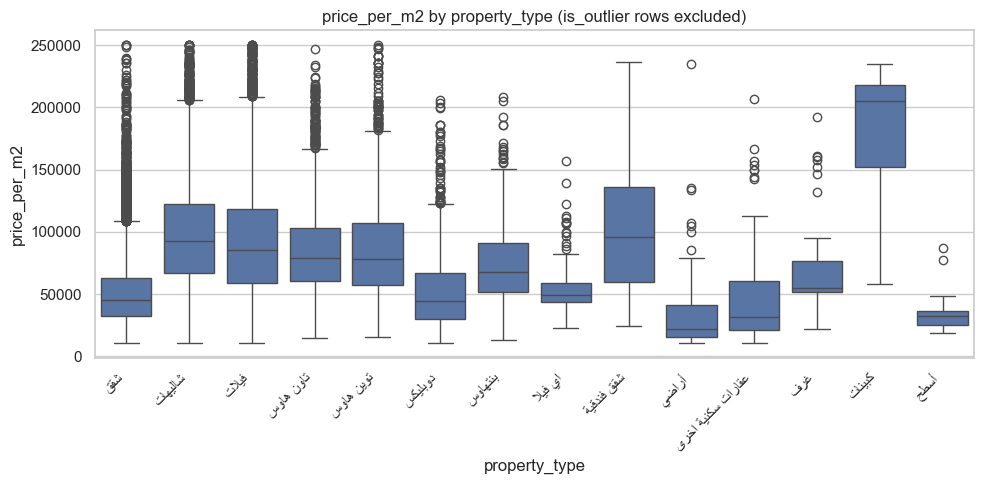

In [8]:
def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(str(text))
    return get_display(reshaped_text)

plt.figure(figsize=(10, 5))

order = df_raw["property_type"].value_counts().index

ax = sns.boxplot(
    data=df_raw[~df_raw["is_outlier"]],
    x="property_type",
    y="price_per_m2",
    order=order,
)

# Fix Arabic labels
ax.set_xticklabels(
    [fix_arabic(label) for label in order],
    rotation=45,
    ha="right"
)

plt.title("price_per_m2 by property_type (is_outlier rows excluded)")

plt.tight_layout()
plt.show()

Different `property_type`s clearly have very different price-per-m² distributions (land vs. apartments vs. villas) -- this is a strong signal the model needs.

## 3. Data Cleaning

Wrapped in a single `clean_data()` function so the exact same logic runs identically every retrain,
not just here in the notebook.

**What gets removed and why:**
- **`property_id`** -- just a row identifier, no predictive value.
- **`price_per_m2`** -- this is `price_egp / area_m2`, computed *from* the target. Keeping it as a
  feature would mean the model just learns to invert a division -- perfect leakage, near-zero
  real-world value.
- **`computed_at`, `days_on_market`** -- in this single snapshot both are constant (one timestamp,
  all zeros), so they carry zero signal right now. Once the pipeline has run a few cycles and these
  vary across snapshots, they become genuinely useful -- see the note in Section 9.
- **Outlier rows** -- `is_outlier == True` rows are dropped, *plus* a second automatic pass: rows
  where `price_per_m2` or `area_m2` fall outside the 0.5th/99.5th percentile **within their own
  `property_type`** (land and villas have very different normal ranges than apartments, so filtering
  needs to happen per-segment, not globally).


In [9]:
LEAKY_OR_USELESS_COLS = ["property_id", "price_per_m2", "computed_at", "days_on_market"]


def filter_segment_outliers(df: pd.DataFrame, cols=("price_per_m2", "area_m2"),
                             lower_q=0.005, upper_q=0.995) -> pd.DataFrame:
    """Drop rows outside the [lower_q, upper_q] percentile range of `cols`,
    computed separately per property_type so land/villas aren't clipped by
    apartment-scale thresholds."""
    keep_mask = pd.Series(True, index=df.index)
    for ptype, group in df.groupby("property_type"):
        for col in cols:
            lo, hi = group[col].quantile([lower_q, upper_q])
            out_of_range = (df.index.isin(group.index)) & ((df[col] < lo) | (df[col] > hi))
            keep_mask &= ~out_of_range
    return df[keep_mask]


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    before = len(df)
    df = df[~df["is_outlier"]]
    df = filter_segment_outliers(df)
    df = df[df["price_egp"] > 0]
    after = len(df)
    print(f"Rows dropped by outlier filtering: {before - after:,} ({(before - after) / before:.1%}) -- {after:,} remain")

    df = df.drop(columns=[c for c in LEAKY_OR_USELESS_COLS if c in df.columns])
    return df


df_clean = clean_data(df_raw)
df_clean.head()


Rows dropped by outlier filtering: 1,719 (3.9%) -- 42,414 remain


,property_type,rooms,baths,area_m2,city,neighbourhood,price_egp,is_outlier,active_listing_count,neighbourhood_avg_price_per_m2
0,شقق,3.0,2.0,192.0,العاصمة الإدارية الجديدة,ار 8,5900000,False,1,33407.865329
1,دوبليكس,3.0,3.0,303.0,العاصمة الإدارية الجديدة,ار 8,10488300,False,1,33407.865329
2,شقق,3.0,2.0,145.0,القاهرة الجديدة,التجمع الخامس,10395000,False,1,72747.554095
3,شقق,4.0,2.0,190.0,سيدي بشر,NaN,4800000,False,1,26455.463042
4,شاليهات,3.0,3.0,160.0,الساحل الشمالي,NaN,19000000,False,1,111647.836111


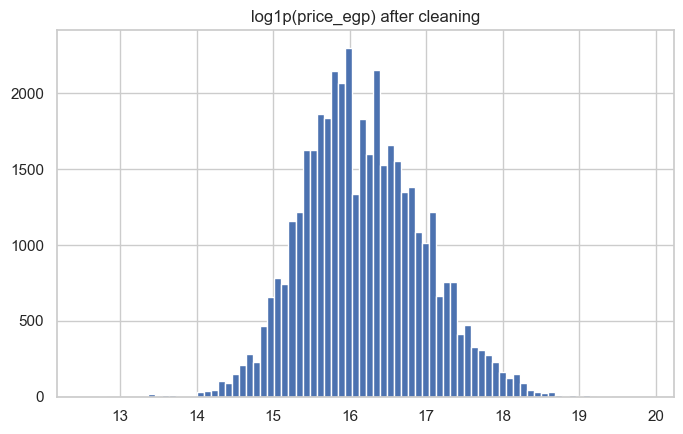

count    4.241400e+04
mean     1.466178e+07
std      1.549304e+07
min      2.800000e+05
25%      6.000000e+06
50%      1.000000e+07
75%      1.788682e+07
max      4.275000e+08
Name: price_egp, dtype: float64


In [10]:
# Re-check the target distribution after cleaning
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(np.log1p(df_clean["price_egp"]), bins=80)
ax.set_title("log1p(price_egp) after cleaning")
plt.tight_layout()
plt.show()
print(df_clean["price_egp"].describe())


## 4. Feature Engineering

Also wrapped in one function (`engineer_features()`) for the same reason -- identical logic every
retrain cycle.

- **`rooms` / `baths`** -- 42 missing each (~0.1%); imputed with the **median for that
  `property_type`** rather than a single global median (a land plot and an apartment don't have
  comparable room counts).
- **`neighbourhood`** -- 31% missing. Rather than dropping the column or the rows, missingness
  itself is kept as a signal: a `neighbourhood_is_known` flag, then nulls filled with `"Unknown"` so
  it's still usable in the target-encoding step below.
- **`city` / `neighbourhood` target encoding** -- both are high-cardinality, so instead of one-hot,
  they're encoded as the (cross-fitted, leakage-safe) mean `price_per_m2` for that city/neighbourhood.
  This uses `sklearn.preprocessing.TargetEncoder`, which internally does K-fold cross-fitting so a
  row's own price never leaks into its own encoded value.
- **`area_per_room`, `bath_to_room_ratio`** -- simple engineered ratios that often carry real signal
  for price (bigger rooms, more bathrooms relative to bedrooms -> higher-end unit).
- **`active_listing_count`** -- right-skewed (mostly 1, a long tail up to 28); log1p-transformed.
- **`property_type`** -- low cardinality (14), one-hot encoded.


In [11]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["rooms"] = df.groupby("property_type")["rooms"].transform(lambda s: s.fillna(s.median()))
    df["baths"] = df.groupby("property_type")["baths"].transform(lambda s: s.fillna(s.median()))
    # fallback in case a property_type has ALL rooms/baths missing (median would still be NaN)
    df["rooms"] = df["rooms"].fillna(df["rooms"].median())
    df["baths"] = df["baths"].fillna(df["baths"].median())

    df["neighbourhood_is_known"] = df["neighbourhood"].notna().astype(int)
    df["neighbourhood"] = df["neighbourhood"].fillna("Unknown")

    df["area_per_room"] = df["area_m2"] / df["rooms"].replace(0, np.nan)
    df["area_per_room"] = df["area_per_room"].fillna(df["area_m2"])  # studios / land (0 rooms)
    df["bath_to_room_ratio"] = df["baths"] / df["rooms"].replace(0, np.nan)
    df["bath_to_room_ratio"] = df["bath_to_room_ratio"].fillna(0)

    df["active_listing_count_log"] = np.log1p(df["active_listing_count"])

    df["log_price"] = np.log1p(df["price_egp"])

    return df


df_feat = engineer_features(df_clean)
df_feat[["rooms", "baths", "neighbourhood_is_known", "area_per_room", "bath_to_room_ratio",
         "active_listing_count_log", "log_price"]].describe()


,rooms,baths,neighbourhood_is_known,area_per_room,bath_to_room_ratio,active_listing_count_log,log_price
count,42414.000000,42414.000000,42414.000000,42414.000000,42414.000000,42414.000000,42414.000000
mean,3.019593,2.797307,0.695289,67.427583,0.917526,0.715871,16.170479
std,1.227756,1.307600,0.460290,152.777910,0.273892,0.124156,0.784170
min,0.000000,0.000000,0.000000,2.857143,0.000000,0.693147,12.542548
25%,2.000000,2.000000,0.000000,50.000000,0.666667,0.693147,15.607270
50%,3.000000,3.000000,1.000000,59.333333,1.000000,0.693147,16.118096
75%,4.000000,3.000000,1.000000,71.428571,1.000000,0.693147,16.699575
max,11.000000,11.000000,1.000000,16800.000000,3.000000,3.367296,19.873465


In [12]:
NUMERIC_FEATURES = [
    "rooms", "baths", "area_m2", "area_per_room", "bath_to_room_ratio",
    "active_listing_count_log", "neighbourhood_avg_price_per_m2", "neighbourhood_is_known",
]
CATEGORICAL_ONEHOT = ["property_type"]
CATEGORICAL_TARGET_ENC = ["city", "neighbourhood"]
TARGET_COL = "log_price"

FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_ONEHOT + CATEGORICAL_TARGET_ENC

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET_COL]
print(X.shape, y.shape)


(42414, 11) (42414,)


> **A note on `neighbourhood_avg_price_per_m2`:** this column comes pre-computed from your Supabase
> pipeline (the neighbourhood's average price/m² across its active listings). It carries a little bit
> of the same-row's own price baked into the average, but with hundreds of listings per neighbourhood
> typically, the per-row influence is small. It's kept as a numeric feature for now since it's a
> genuinely strong signal, but flagged here so you're aware -- if you ever see suspiciously perfect
> validation scores, this is the first column to double-check.


## 5. Train / Test Split

Right now this is a **single snapshot**, so a random split is the only option. Once the pipeline has
been running for a few 2-week cycles and you have multiple `computed_at` snapshots, switch this to a
**time-based split** (train on older snapshots, test on the newest) -- a random split will start
overestimating real-world performance once there's a time dimension to exploit. Noted again in
Section 9.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")


Train: 33,931 rows | Test: 8,483 rows


## 6. Preprocessing Pipeline + Model Comparison

Everything (imputation is already done, so just encoding/scaling here) is wrapped in a
`ColumnTransformer` so it's part of one sklearn `Pipeline` object per model -- meaning the exact same
saved artifact can preprocess *and* predict on new raw rows later, with no risk of the encoding logic
drifting out of sync between training and inference.

Four candidates, compared with 5-fold cross-validation on the training set:
1. **Dummy (median)** -- sanity-check floor; any real model must beat this by a wide margin.
2. **Ridge regression** -- fast linear baseline.
3. **Random Forest** -- robust, handles non-linearity, minimal tuning needed.
4. **HistGradientBoosting** (sklearn built-in) and **LightGBM** -- typically the strongest performers
   for structured/tabular data like this.


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_ONEHOT),
        ("target_enc", TargetEncoder(random_state=RANDOM_STATE), CATEGORICAL_TARGET_ENC),
    ],
    remainder="drop",
)

models = {
    "Dummy (median)": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        random_state=RANDOM_STATE, verbosity=-1,
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=-1,
    )
    results.append({
        "model": name,
        "MAE (log scale)": -scores["test_mae"].mean(),
        "RMSE (log scale)": -scores["test_rmse"].mean(),
        "R2": scores["test_r2"].mean(),
    })
    print(f"{name:22s} done")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


Dummy (median)         done
Ridge                  done
RandomForest           done
HistGradientBoosting   done
LightGBM               done


,model,MAE (log scale),RMSE (log scale),R2
0,LightGBM,0.242573,0.319485,0.834492
1,RandomForest,0.236506,0.321123,0.832792
2,HistGradientBoosting,0.252588,0.329171,0.824307
3,Ridge,0.316398,0.406107,0.732607
4,Dummy (median),0.628256,0.787195,-0.004444


The best-performing model (highest R², lowest error) will be trained on the full training set and evaluated on the held-out test set below.

## 7. Final Model — Fit, Evaluate on Test Set, Feature Importance

Errors are reported **back on the original EGP scale** (not the log scale used for training) so
they're actually interpretable -- "average error of X EGP", not "average error of 0.14 log-units".


In [15]:
BEST_MODEL_NAME = results_df.iloc[0]["model"]
print(f"Best model by CV R2: {BEST_MODEL_NAME}")

final_pipe = Pipeline([("prep", preprocessor), ("model", models[BEST_MODEL_NAME])])
final_pipe.fit(X_train, y_train)

y_pred_log = final_pipe.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)
mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

print(f"Test MAE:  {mae:,.0f} EGP")
print(f"Test RMSE: {rmse:,.0f} EGP")
print(f"Test R2:   {r2:.4f}")
print(f"Test MAPE: {mape:.1f}%")


Best model by CV R2: LightGBM
Test MAE:  3,690,264 EGP
Test RMSE: 8,483,056 EGP
Test R2:   0.7188
Test MAPE: 25.0%


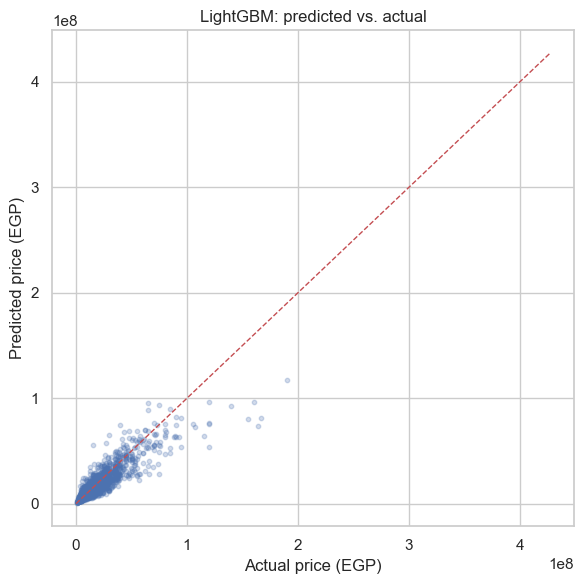

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
sample = min(3000, len(y_true))
idx = np.random.RandomState(RANDOM_STATE).choice(len(y_true), sample, replace=False)
ax.scatter(y_true.values[idx], y_pred[idx], alpha=0.25, s=10)
lims = [0, max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual price (EGP)")
ax.set_ylabel("Predicted price (EGP)")
ax.set_title(f"{BEST_MODEL_NAME}: predicted vs. actual")
plt.tight_layout()
plt.show()


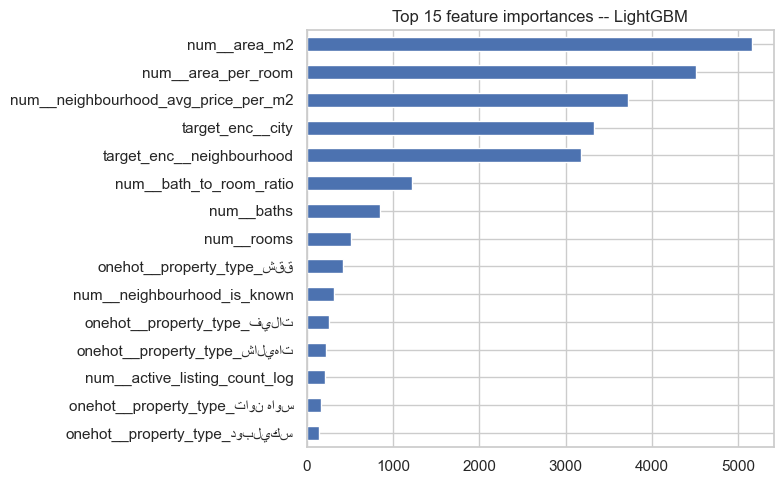

In [17]:
# Feature importance (tree-based models only -- skip gracefully for Ridge/Dummy)
model_step = final_pipe.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    feature_names = final_pipe.named_steps["prep"].get_feature_names_out()
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    importances.iloc[::-1].plot(kind="barh")
    plt.title(f"Top 15 feature importances -- {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{BEST_MODEL_NAME} doesn't expose feature_importances_ (linear model) -- check coefficients instead.")


## 8. Save the Pipeline + a Reusable `retrain()` Function

Everything from Sections 3-7 is now collapsed into one function, `retrain()`, that takes a raw CSV
path and produces a ready-to-use fitted pipeline. This is the piece that would get called by whatever
runs on the 2-week schedule (cron, Airflow, a simple `systemd` timer, a scheduled cloud function --
whatever you're already using to land data into Supabase).


In [18]:
def retrain(data_path: str, model_name: str = None, save_path: str = "price_model_pipeline.joblib"):
    """Full retrain from a raw CSV export to a saved, ready-to-serve pipeline.
    Pass model_name to force a specific model; otherwise re-runs the CV
    comparison and picks the best one automatically (slower, but keeps
    picking the best model as the data distribution evolves over time)."""
    raw = pd.read_csv(data_path)
    cleaned = clean_data(raw)
    feat = engineer_features(cleaned)

    X_full = feat[FEATURE_COLS]
    y_full = feat[TARGET_COL]

    if model_name is None:
        cv_local = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scored = []
        for name, model in models.items():
            if name == "Dummy (median)":
                continue
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            r2_scores = cross_validate(pipe, X_full, y_full, cv=cv_local, scoring="r2", n_jobs=-1)
            scored.append((name, r2_scores["test_score"].mean()))
        model_name = max(scored, key=lambda t: t[1])[0]

    pipe = Pipeline([("prep", preprocessor), ("model", models[model_name])])
    pipe.fit(X_full, y_full)

    joblib.dump({"pipeline": pipe, "model_name": model_name, "feature_cols": FEATURE_COLS}, save_path)
    print(f"Retrained with {model_name} on {len(feat):,} rows -> saved to {save_path}")
    return pipe


def predict_price(pipeline, new_rows: pd.DataFrame) -> np.ndarray:
    """new_rows must contain the same raw columns as the original CSV
    (property_type, rooms, baths, area_m2, city, neighbourhood,
    active_listing_count, neighbourhood_avg_price_per_m2, is_outlier).
    Runs the same clean_data + engineer_features steps, then predicts."""
    cleaned = clean_data(new_rows.assign(price_egp=new_rows.get("price_egp", 1)))  # placeholder if unknown
    feat = engineer_features(cleaned)
    log_pred = pipeline.predict(feat[FEATURE_COLS])
    return np.expm1(log_pred)


In [19]:
# Save using the model already selected above (skip re-running CV again here since we just did it)
joblib.dump(
    {"pipeline": final_pipe, "model_name": BEST_MODEL_NAME, "feature_cols": FEATURE_COLS},
    "price_model_pipeline.joblib",
)
print("Saved: price_model_pipeline.joblib")


Saved: price_model_pipeline.joblib


In [20]:
# Quick sanity check: reload from disk and confirm predictions match
loaded = joblib.load("price_model_pipeline.joblib")
reloaded_pred = np.expm1(loaded["pipeline"].predict(X_test))
print("Max diff vs. in-memory predictions:", np.max(np.abs(reloaded_pred - y_pred)))


Max diff vs. in-memory predictions: 0.0


## 9. Notes for the Recurring (Every-2-Weeks) Pipeline

This notebook is meant to be **read and tested first** -- here's what changes once it's wired into
an actual schedule:

1. **Extract `clean_data()`, `engineer_features()`, `retrain()`, `predict_price()` into a plain
   `.py` module** (e.g. `pipeline.py`) that both this notebook and a scheduled job can import. Keeping
   the logic in one place means the notebook and the automated job can never silently drift apart.

2. **`computed_at` and `days_on_market` become real signal once there are multiple snapshots.**
   Right now both are dropped because they're constant in a single-snapshot export. Once you're
   accumulating snapshots every 2 weeks, re-add them: `computed_at` as a proper datetime feature
   (or at minimum, keep only the *latest* snapshot per `property_id` before training, to avoid
   training on stale duplicate listings), and `days_on_market` as a real numeric feature once it's
   actually being tracked over time.

3. **Switch to a time-based validation split.** With only one snapshot, a random 80/20 split is the
   only option. Once you have several snapshots, validating on a random split will overestimate
   real-world accuracy (the model gets to "see" listings from the same time period it's tested on).
   Switch `train_test_split` to something like: train on all snapshots except the most recent, test
   on the most recent one.

4. **Watch for `property_type`/`city` categories that don't reappear.** `OneHotEncoder(handle_unknown="ignore")`
   already protects against a genuinely new `property_type` showing up; `TargetEncoder` handles
   unseen categories similarly by falling back to the global mean. Nothing to change here, just worth
   knowing the pipeline already tolerates this.

5. **Re-run the model comparison (Section 6) periodically, not just once.** As more data accumulates,
   a different model (or different hyperparameters) may start winning. `retrain()` above already
   supports re-running the comparison automatically (`model_name=None`) -- worth doing every few
   cycles rather than assuming today's winner stays the winner forever.

6. **Set a monitoring threshold.** Once this is automated and nobody's watching every run, add a
   simple check after each `retrain()`: if the new model's test MAE/R² is meaningfully worse than the
   last saved one, alert instead of silently overwriting `price_model_pipeline.joblib` with a worse
   model (e.g. caused by a bad upstream data pull).
